# 📊 Exploratory Data Analysis (EDA) — Fantasy Premier League 2024/2025

## 1. Introdução

Este notebook apresenta uma Análise Exploratória de Dados (EDA) realizada sobre um conjunto de dados proveniente do repositório público *Fantasy Premier League (FPL)*, disponível em:
https://github.com/vaastav/Fantasy-Premier-League

O objetivo central da análise é preparar um dataset limpo, estruturado e apropriado para a aplicação de algoritmos de **mineração de regras de associação**, recorrendo à informação de desempenho dos jogadores ao longo das jornadas da época 2024/2025. Toda a investigação é conduzida com foco na identificação de padrões entre eventos de jogo, métricas de performance e resultados estatísticos dos jogadores.

### 1.1. O que é o Fantasy Premier League?

O *Fantasy Premier League* (FPL) é um jogo global onde milhões de utilizadores constroem equipas virtuais constituídas por jogadores reais da **Premier League inglesa**.  
Em cada jornada, os jogadores acumulam pontos com base no seu desempenho real: golos, assistências, clean sheets, minutos jogados, bónus, entre outros critérios.

O repositório utilizado nesta análise contém extrações completas da API do FPL, reunindo milhares de registos sobre estatísticas detalhadas de cada jogador em cada jornada, variando entre métricas tradicionais (golos, assistências) e métricas derivadas (influence, threat, creativity).


### 1.2. Seleção do dataset `merged_gw.csv`

Apesar de o repositório conter dezenas de ficheiros com diferentes tipos de dados (preços, estatísticas históricas, equipas, metadata de jogadores, etc.), apenas um ficheiro foi selecionado:

**`data/2024-25/gws/merged_gw.csv`**

Este dataset agrega, numa única estrutura, **todos os eventos registados em cada jornada**, para cada jogador, incluindo:

- pontos,
- minutos jogados,
- ações ofensivas e defensivas,
- contribuições esperadas (xG, xA),
- métricas avançadas,
- preço e variações,
- dados de posse e seleção,
- ações relevantes para a performance individual.

Este conjunto de dados é ideal para regras de associação, uma vez que cada linha representa uma "transação" de performance do jogador numa jornada, permitindo identificar padrões entre diferentes características.


### 1.3. Objetivo do notebook

O objetivo deste notebook consiste em:

1. Descrever e compreender o dataset selecionado.  
2. Realizar uma EDA aprofundada, abrangendo:
   - estrutura dos dados,  
   - análise estatística,  
   - identificação de problemas,  
   - tratamento e limpeza,  
   - estudo de distribuições e correlações.
3. Transformar variáveis contínuas em atributos binários adequados ao algoritmo Apriori.
4. Construir um dataset final preparado para extração de regras de associação.

Ao final da EDA, o dataset estará limpo, consistente e devidamente transformado, constituindo a base para a fase de mineração de padrões.

---

## 2. Carregamento do Dataset

Para iniciar a EDA, procede-se ao carregamento das principais bibliotecas necessárias para manipulação e visualização dos dados, seguido da leitura do ficheiro `merged_gw.csv`, localizado na estrutura de pastas do repositório.

Este ficheiro localmente encontra-se na pasta `data\merger_gw.csv`

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# use a more tolerant CSV parser to skip malformed lines that cause the ParserError
df = pd.read_csv("data/merged_gw.csv", engine='python', sep=',', on_bad_lines='skip')

df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,0.01,0.01,0.0,1.02,6,1,0,3.6,22.8,2024-08-17T14:00:00Z,62,False,16,0,0,0,0,1,0,4339,1,1,1,0.0,2,0,0,0,50,False,0,1
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,0.00,0.00,0.0,0.00,6,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,3,0,0,0,0,1,0,33324,0,1,1,0.0,0,0,0,0,45,True,0,1
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,0.00,0.00,0.0,0.00,2,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,20,0,0,0,0,1,0,8462,0,0,2,0.0,0,0,0,0,50,True,0,1
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,0.00,0.00,0.0,0.00,8,0,0,0.0,0.0,2024-08-18T13:00:00Z,0,False,4,0,0,0,0,1,0,716,0,1,2,0.0,0,0,0,0,45,False,0,1
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,0.02,0.32,0.3,0.25,5,1,0,3.3,2.6,2024-08-17T14:00:00Z,70,False,15,0,0,0,0,1,0,66244,1,0,1,16.0,1,0,0,0,55,False,1,1


---

## 3. Estrutura do Dataset

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14178 entries, 0 to 14177
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        14178 non-null  object 
 1   position                    14178 non-null  object 
 2   team                        14178 non-null  object 
 3   xP                          14178 non-null  float64
 4   assists                     14178 non-null  int64  
 5   bonus                       14178 non-null  int64  
 6   bps                         14178 non-null  int64  
 7   clean_sheets                14178 non-null  int64  
 8   creativity                  14178 non-null  float64
 9   element                     14178 non-null  int64  
 10  expected_assists            14178 non-null  float64
 11  expected_goal_involvements  14178 non-null  float64
 12  expected_goals              14178 non-null  float64
 13  expected_goals_conceded     141

In [16]:
df.describe(include='all')

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
count,14178,14178,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.00000,14178.000000,14178.000000,14178.000000,14178.000000,14178,14178.000000,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,1.417800e+04,1.417800e+04,14178.000000,14178,14178.000000,14178.000000
unique,724,4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,Raúl Jiménez,MID,Brighton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-21T14:00:00Z,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
freq,21,6436,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398,NaN,14178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7110,NaN,NaN
mean,NaN,NaN,NaN,1.174129,0.038369,0.093031,5.023769,0.076456,4.679539,340.039780,0.028891,0.073158,0.044272,0.481510,107.65115,0.483354,0.042742,1.566695,6.752560,NaN,29.035478,NaN,10.495204,0.001199,0.000564,0.000564,0.001975,11.215475,0.094442,2.330977e+05,0.324305,1.480251,1.521865,4.249189,1.203061,4.119439e+01,1.829234e+04,1.825072e+04,49.558400,NaN,0.065454,11.215475
std,NaN,NaN,NaN,1.794372,0.208977,0.456648,9.576491,0.265736,10.607323,196.844226,0.087781,0.193644,0.151994,0.783524,60.55080,0.934950,0.223804,2.828839,12.586388,NaN,38.554664,NaN,5.768158,0.036589,0.023748,0.023748,0.044397,6.046624,0.642730,6.312137e+05,0.468131,1.266242,1.186369,10.993013,2.361287,8.109667e+04,6.851884e+04,6.286187e+04,10.509246,NaN,0.247333,6.046624
min,NaN,NaN,NaN,-2.200000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,39.000000,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,169.000000,0.000000,0.000000,0.000000,0.000000,55.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,5.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,5.575250e+03,0.000000,1.000000,1.000000,0.000000,0.000000,-1.894000e+03,5.700000e+01,2.410000e+02,44.000000,NaN,0.000000,6.000000
50%,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,340.000000,0.000000,0.000000,0.000000,0.000000,108.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,10.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,2.414700e+04,0.000000,1.000000,1.000000,0.000000,0.000000,-1.650000e+02,5.730000e+02,1.560000e+03,47.000000,NaN,0.000000,11.000000
75%,NaN,NaN,NaN,2.000000,0.000000,0.000000,6.000000,0.000000,2.500000,509.000000,0.010000,0.030000,0.000000,0.820000,161.00000,1.000000,0.000000,2.200000,9.200000,NaN,76.000000,NaN,15.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,1.563465e+05,1.000000,2.000000,2.000000,2.000000,1.000000,2.800000e+01,5.843250e+03,1.008375e+04,52.000000,NaN,0.000000,17.000000


### **3.1 Remoção de Atributos Irrelevantes**

Nesta secção procede-se à eliminação de atributos considerados irrelevantes ou prejudiciais para o processo de modelação com regras de associação. Dado que o objetivo consiste em identificar padrões na performance dos jogadores por jornada, é essencial manter apenas variáveis que representem eventos, desempenhos e características diretamente relacionadas ao jogo.

A eliminação dos atributos foi guiada por três critérios principais:

#### **a) Atributos que não contribuem para padrões de desempenho**
Variáveis como `name`, `element`, `team_h_score` e `team_a_score` não representam comportamentos relacionáveis entre si (ex.: não é útil descobrir que “quando o elemento 123 joga, o elemento 456 marca golo”).  
Da mesma forma, o identificador do jogador (`element`) e o nome não carregam qualquer valor analítico para regras de associação.

#### **b) Variáveis altamente derivadas, redundantes ou duplicadas**
Atributos como `expected_goals`, `expected_assists` e `expected_goal_involvements` são fortemente correlacionados entre si, podendo introduzir redundância.  
Neste contexto, mantém-se apenas `expected_goal_involvements`, por ser a métrica mais abrangente das três.

#### **c) Atributos irrelevantes para o contexto de performance**
Variáveis administrativas ou logísticas, como:
- `kickoff_time`
- `modified`
- `fixture`
- `opponent_team`

não têm impacto direto na performance ou não são expressivas para regras de associação.

Além disso, variáveis relacionadas a transferências e seleção (`selected`, `transfers_in`, `transfers_out`, `transfers_balance`) representam comportamento dos utilizadores e não dos jogadores, o que foge ao objetivo definido: **descobrir padrões na performance e não nas escolhas dos managers**.

#### **Atributos mantidos**
Foram mantidos atributos que expressam eventos reais do jogo ou métricas consolidáveis num formato categórico, tais como:
- `goals_scored`, `assists`, `clean_sheets`, `bonus`
- `minutes`, `starts`
- `yellow_cards`, `red_cards`, `penalties_missed`, `penalties_saved`
- Métricas compostas como: `ict_index`, `influence`, `creativity`, `threat`
- KPI final: `total_points`
- Informação contextual reduzida: `position`, `team`, `GW`, `was_home`

A manutenção destes atributos permite que, numa fase posterior, sejam discretizados ou transformados em variáveis binárias representando eventos (ex.: “marcou golo”, “teve mais de X pontos”), adequando o dataset ao algoritmo Apriori.

Após esta análise, procede-se à eliminação programática das colunas redundantes ou irrelevantes.

In [18]:
# Lista de colunas a eliminar com base na análise anterior
cols_to_drop = [
    # Identificadores ou atributos sem valor analítico
    "name", "element", "kickoff_time", "modified",

    # Altamente correlacionados — manter apenas expected_goal_involvements
    "expected_goals", "expected_assists",

    # Atributos irrelevantes para performance
    "fixture", "opponent_team",

    # Comportamento dos utilizadores (não da performance real)
    "transfers_balance", "transfers_in", "transfers_out", "selected",

    # Scores globais que não representam ação individual
    "team_h_score", "team_a_score",

    # Atributo redundante com GW
    "round"
]

# Remoção das colunas
df_cleaned = df.drop(columns=cols_to_drop)

# Mostrar resultado
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14178 entries, 0 to 14177
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   position                    14178 non-null  object 
 1   team                        14178 non-null  object 
 2   xP                          14178 non-null  float64
 3   assists                     14178 non-null  int64  
 4   bonus                       14178 non-null  int64  
 5   bps                         14178 non-null  int64  
 6   clean_sheets                14178 non-null  int64  
 7   creativity                  14178 non-null  float64
 8   expected_goal_involvements  14178 non-null  float64
 9   expected_goals_conceded     14178 non-null  float64
 10  goals_conceded              14178 non-null  int64  
 11  goals_scored                14178 non-null  int64  
 12  ict_index                   14178 non-null  float64
 13  influence                   141

---

## 4. Análise de Valores Nulos

A presença de valores nulos é comum em datasets provenientes da API do FPL, sobretudo porque determinadas métricas não se aplicam a todas as posições (por exemplo, guarda-redes não marcam golos; avançados não fazem defesas).

Nesta fase:

- identifica-se a quantidade de valores em falta por atributo;
- avalia-se a relevância de cada atributo;
- decide-se se os valores nulos devem ser mantidos, imputados ou convertidos para um valor indicativo.

A maioria dos atributos será mantida tal como está, devido à sua natureza posicional.

In [6]:
df_cleaned.isna().sum().sort_values(ascending=False)

position                      0
team                          0
xP                            0
assists                       0
bonus                         0
bps                           0
clean_sheets                  0
creativity                    0
expected_goal_involvements    0
expected_goals_conceded       0
goals_conceded                0
goals_scored                  0
ict_index                     0
influence                     0
minutes                       0
own_goals                     0
penalties_missed              0
penalties_saved               0
red_cards                     0
round                         0
saves                         0
starts                        0
threat                        0
total_points                  0
value                         0
was_home                      0
yellow_cards                  0
GW                            0
dtype: int64

---

## 5. One-Hot Encoding das Variáveis Categóricas (`position` e `team`)

O dataset contém duas variáveis categóricas essenciais para a análise de desempenho dos jogadores:  
- **`position`** (GKP, DEF, MID, FWD)  
- **`team`** (equipa do jogador em cada jornada)

Para que estas variáveis possam ser utilizadas num modelo de regras de associação, é necessário convertê-las para um formato binário. O algoritmo Apriori não consegue interpretar texto ou categorias, exigindo que cada possível categoria seja representada por uma variável independente.

Neste contexto, é aplicado **one-hot encoding**, que transforma cada categoria numa coluna distinta contendo valores binários (0 ou 1). Por exemplo:
- A variável `position` passa a ser representada por colunas como `pos_DEF`, `pos_MID`, `pos_FWD` e `pos_GKP`.
- A variável `team` desdobra-se em múltiplas colunas, uma para cada equipa da Premier League, como `team_Arsenal`, `team_Liverpool`, `team_Man City`, entre outras.

Esta transformação permite:
1. **Representar categorias de forma explícita e independente**, facilitando a criação de regras como “DEFESA + CLEAN SHEET → ALTA PONTUAÇÃO”.
2. **Preparar os dados para o processo de binarização**, etapa crucial para a construção da matriz transacional utilizada pelo Apriori.
3. **Manter granularidade sem perda de informação**, permitindo que padrões específicos por posição ou equipa sejam descobertos.

Após a aplicação do one-hot encoding, o dataset fica totalmente compatível com o processo de discretização e posterior mineração de regras de associação.

In [20]:
import pandas as pd 

df_onehot = df_cleaned.copy()

df_onehot = pd.get_dummies(df_onehot, columns=['position', 'team'],prefix=["pos", "team"], dtype=int)

df_onehot.head()

,xP,assists,bonus,bps,clean_sheets,creativity,expected_goal_involvements,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,penalties_saved,red_cards,saves,starts,threat,total_points,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Ipswich,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves
0,1.6,0,0,11,0,12.8,0.01,1.02,1,0,3.6,22.8,62,0,0,0,0,0,1,0.0,2,50,False,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2.2,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,45,True,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0.0,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,50,True,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.0,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,45,False,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.0,0,0,-2,0,14.0,0.32,0.25,1,0,3.3,2.6,70,0,0,0,0,0,1,16.0,1,55,False,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


---

## 6. Binarização e Discretização das Variáveis Numéricas

O algoritmo Apriori exige que todas as variáveis estejam num formato binário, representando a presença ou ausência de um atributo.  
Como o dataset contém numerosas variáveis numéricas com diferentes escalas, é necessário convertê-las para atributos discretos antes da geração da matriz transacional.

Para isso, adotam-se duas estratégias principais:

#### **1. Binarização lógica para atributos de contagem**
Colunas onde um valor maior que zero representa diretamente um evento relevante (como golos, assistências ou cartões) são transformadas em variáveis binárias:

- `goals_scored` → `1` se o jogador marcou, caso contrário `0`
- `assists` → `1` se assistiu
- `clean_sheets` → `1` se manteve a baliza inviolada
- `yellow_cards`, `red_cards`, etc.

Esta abordagem permite gerar regras como:

> *“Jogador marcou e esteve a jogar em casa → alta probabilidade de obter bonus.”*


#### **2. Discretização por faixas para variáveis contínuas**
Variáveis como `ict_index`, `creativity`, `influence`, `threat`, e métricas expected (xG, xA, etc.) não podem ser simplesmente binarizadas.  
Em vez disso, são divididas em **tercis** (baixa, média, alta), permitindo padrões mais expressivos.

Exemplo:
- `influence` → `inf_low`, `inf_med`, `inf_high`
- `total_points` → `points_low`, `points_med`, `points_high`

Esta discretização permite descobrir relações como:

> *“Jogadores com alta influência e alta criatividade tendem a obter pontuações elevadas.”*

#### **3. Conversão explícita de variáveis booleanas**

Colunas booleanas, como `was_home`, são convertidas para valores 0/1 para compatibilidade com Apriori.

Após esta etapa, todas as variáveis ficam preparadas para compor a matriz binária final, permitindo extrair padrões interpretáveis sobre o desempenho dos jogadores.

In [23]:
import pandas as pd

df_bin = df_onehot.copy()

# =========================
# 1. Binarização direta (>=1 -> 1)
# =========================
binary_cols = [
    "goals_scored", "assists", "clean_sheets", "yellow_cards",
    "red_cards", "own_goals", "penalties_saved", "penalties_missed",
    "saves", "starts"
]

for col in binary_cols:
    df_bin[col] = (df_bin[col] >= 1).astype(int)

# =========================
# 2. Binarização de minutos
# =========================
df_bin["played_60+"] = (df_bin["minutes"] >= 60).astype(int)
df_bin["played_1+"] = (df_bin["minutes"] >= 1).astype(int)

# (opcional: remover a coluna original)
df_bin.drop(columns=["minutes"], inplace=True)

# =========================
# 3. Discretização em tercis para colunas contínuas
# =========================
continuous_cols = [
    "ict_index", "creativity", "influence", "threat",
    "expected_goal_involvements", "expected_goals_conceded",
    "xP"
]

for col in continuous_cols:
    # Use qcut without labels, then assign labels based on actual number of bins
    bins = pd.qcut(df_bin[col], q=3, duplicates='drop', retbins=False)
    df_bin[col + "_tier"] = bins
    df_bin.drop(columns=[col], inplace=True)

# =========================
# 4. Discretização da pontuação total
# =========================
df_bin["points_tier"] = pd.qcut(df_bin["total_points"], q=3, duplicates='drop')
df_bin.drop(columns=["total_points"], inplace=True)

# =========================
# 5. Conversão de variáveis booleanas
# =========================
df_bin["was_home"] = df_bin["was_home"].astype(int)

# =========================
# 6. Discretização do valor (uma proxy de preço "baixo/médio/alto")
# =========================
df_bin["value_tier"] = pd.qcut(df_bin["value"], q=3, labels=["cheap", "mid", "exp"], duplicates='drop')
df_bin.drop(columns=["value"], inplace=True)

# Verificar resultado final
df_bin.head()


,assists,bonus,bps,clean_sheets,goals_conceded,goals_scored,own_goals,penalties_missed,penalties_saved,red_cards,saves,starts,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Ipswich,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves,played_60+,played_1+,ict_index_tier,creativity_tier,influence_tier,threat_tier,expected_goal_involvements_tier,expected_goals_conceded_tier,xP_tier,points_tier,value_tier
0,0,0,11,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,"(1.2, 28.6]","(0.8, 114.3]","(3.8, 149.0]","(-0.001, 120.0]","(-0.001, 0.01]","(0.41, 5.43]","(1.3, 15.5]","(1.0, 25.0]",mid
1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"(-0.001, 1.2]","(-0.001, 0.8]","(-0.001, 3.8]","(-0.001, 120.0]","(-0.001, 0.01]","(-0.001, 0.41]","(1.3, 15.5]","(-5.001, 0.0]",cheap
2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"(-0.001, 1.2]","(-0.001, 0.8]","(-0.001, 3.8]","(-0.001, 120.0]","(-0.001, 0.01]","(-0.001, 0.41]","(-2.201, 0.0]","(-5.001, 0.0]",mid
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"(-0.001, 1.2]","(-0.001, 0.8]","(-0.001, 3.8]","(-0.001, 120.0]","(-0.001, 0.01]","(-0.001, 0.41]","(-2.201, 0.0]","(-5.001, 0.0]",cheap
4,0,0,-2,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,"(1.2, 28.6]","(0.8, 114.3]","(-0.001, 3.8]","(-0.001, 120.0]","(0.01, 3.03]","(-0.001, 0.41]","(0.0, 1.3]","(0.0, 1.0]",exp


---

## 6. Análise Univariada

Nesta secção exploram-se as distribuições individuais de variáveis importantes, nomeadamente:

- total_points  
- minutes  
- goals_scored  
- assists  
- yellow_cards  
- red_cards  
- own_goals
- penalties_missed
- penalties_saved

O objetivo é perceber o comportamento geral das métricas, identificar assimetrias, dispersões e possíveis padrões que possam ser relevantes para o Apriori.

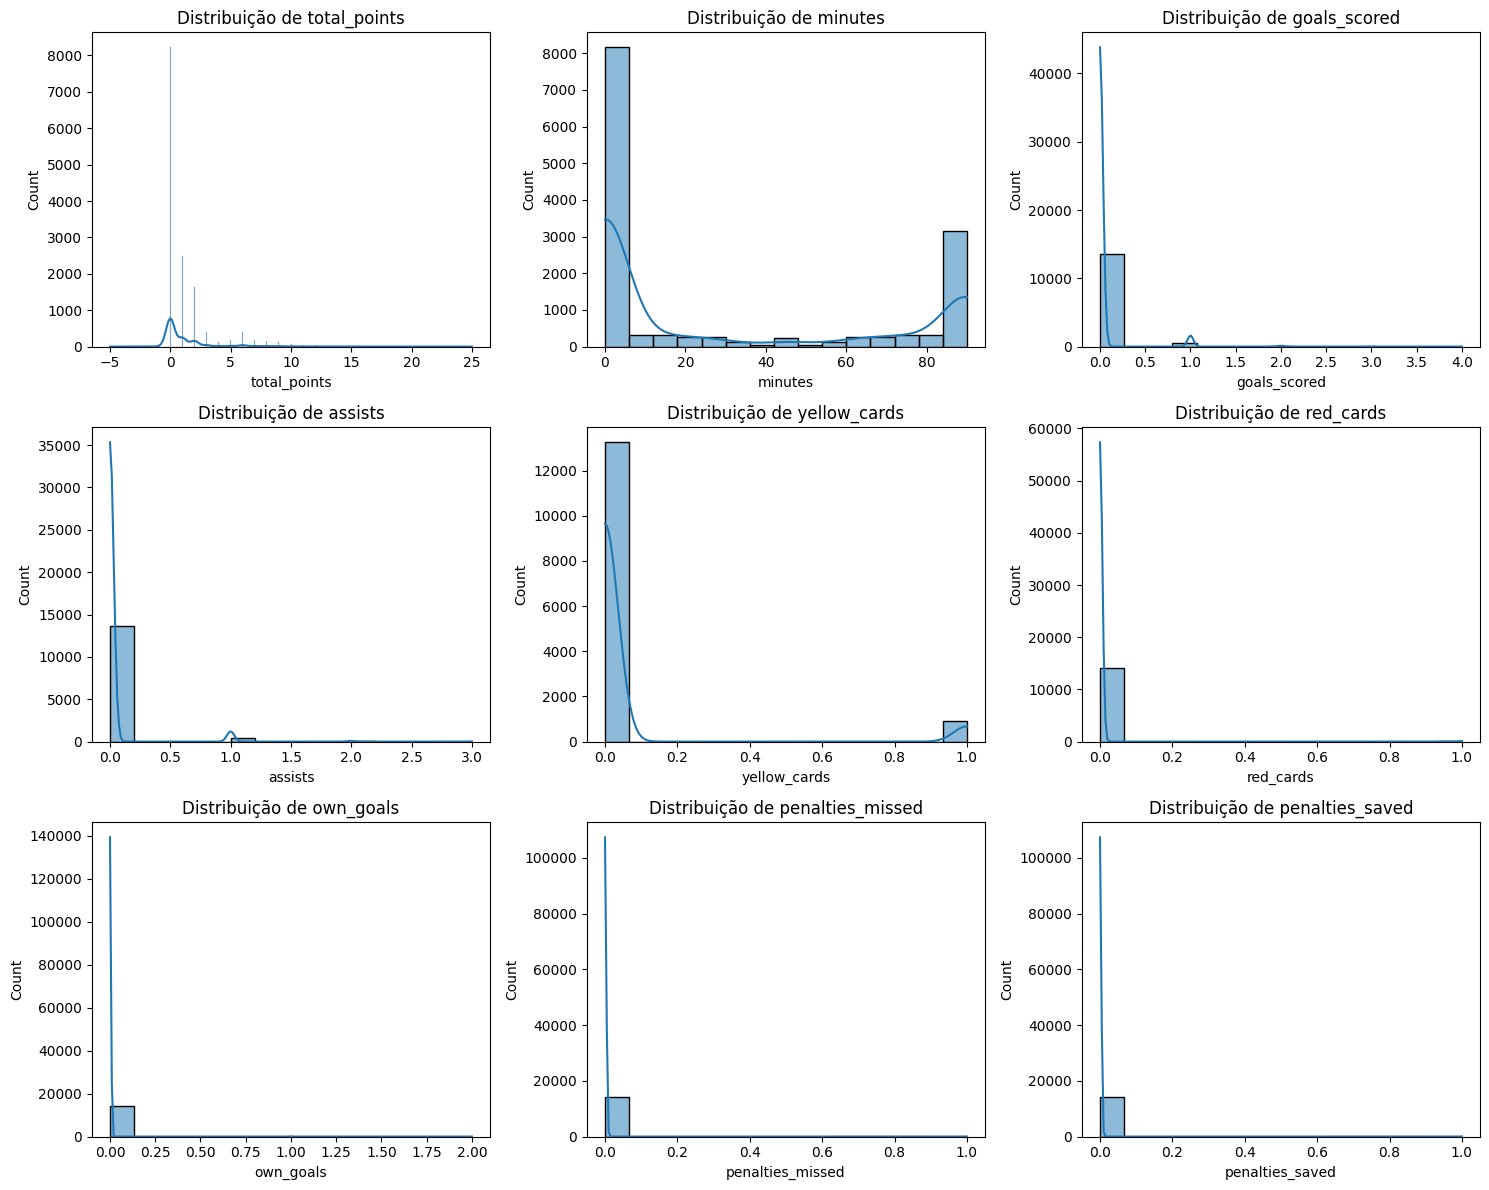

In [22]:
cols_to_plot = ['total_points', 'minutes', 'goals_scored', 'assists', 'yellow_cards', 'red_cards', 'own_goals', 'penalties_missed', 'penalties_saved']

# choose number of columns for the subplot grid and compute required rows
n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(5 * n_cols, 4 * n_rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()


### 6.1 Interpretação Visual das Distribuições

A inspeção visual dos histogramas e das curvas de densidade (KDE) gerados acima revela padrões estruturais fundamentais no comportamento dos jogadores da Fantasy Premier League, que ditam a estratégia de pré-processamento subsequente:

#### 6.1.1 Fenómeno de "Inflação de Zeros" (Eventos Raros)

Observa-se que as variáveis goals_scored, assists, yellow_cards, red_cards, own_goals, penalties_missed e penalties_saved possuem uma distribuição extremamente concentrada no valor zero.

- **Interpretação**: A grande maioria dos jogadores, numa dada jornada, não realiza estas ações. Marcar um golo ou levar um cartão são eventos "esparsos".

- **Implicação**: Tentar prever a quantidade exata (ex: 1 golo vs 2 golos) em regras de associação pode gerar ruído excessivo. O sinal mais forte para o algoritmo é binário: o evento ocorreu ou não?

#### 6.1.2 Bimodalidade na Variável ``minutes``

O gráfico de minutes não segue uma distribuição normal. Pelo contrário, apresenta dois picos distintos nas extremidades:

- Um pico massivo em 0 minutos (jogadores que não entraram em campo).

- Um pico elevado perto dos 90 minutos (titulares que completaram o jogo).

- Uma densidade baixa e irregular entre 1 e 89 minutos.

- **Implicação**: A média não é um bom descritor. É necessário segmentar esta variável em categorias lógicas (Não jogou, Jogou pouco, Jogou muito/tudo).

#### 6.1.3 Assimetria à Direita em ``total_points``

A distribuição de pontos apresenta uma cauda longa à direita (assimetria positiva). A maioria das observações concentra-se entre 0 e 2 pontos (jogadores que não jogaram ou apenas cumpriram tempo sem retorno), enquanto pontuações elevadas (>10) são outliers.

- **Implicação**: Para descobrir regras associadas a "sucesso" (pontuação alta), é necessário transformar esta variável contínua em faixas qualitativas (ex: Baixo, Médio, Alto).

---

## 7. Análise Multivariada

Para compreender a relação entre métricas distintas, procede-se à visualização da matriz de correlação.  
Esta técnica ajuda a identificar padrões relevantes, como:

- métricas que se movem em conjunto,
- indicadores fortemente associados a pontuação,
- atributos redundantes.

Este conhecimento é essencial para inspirar a engenharia de atributos utilizada pelo algoritmo Apriori.


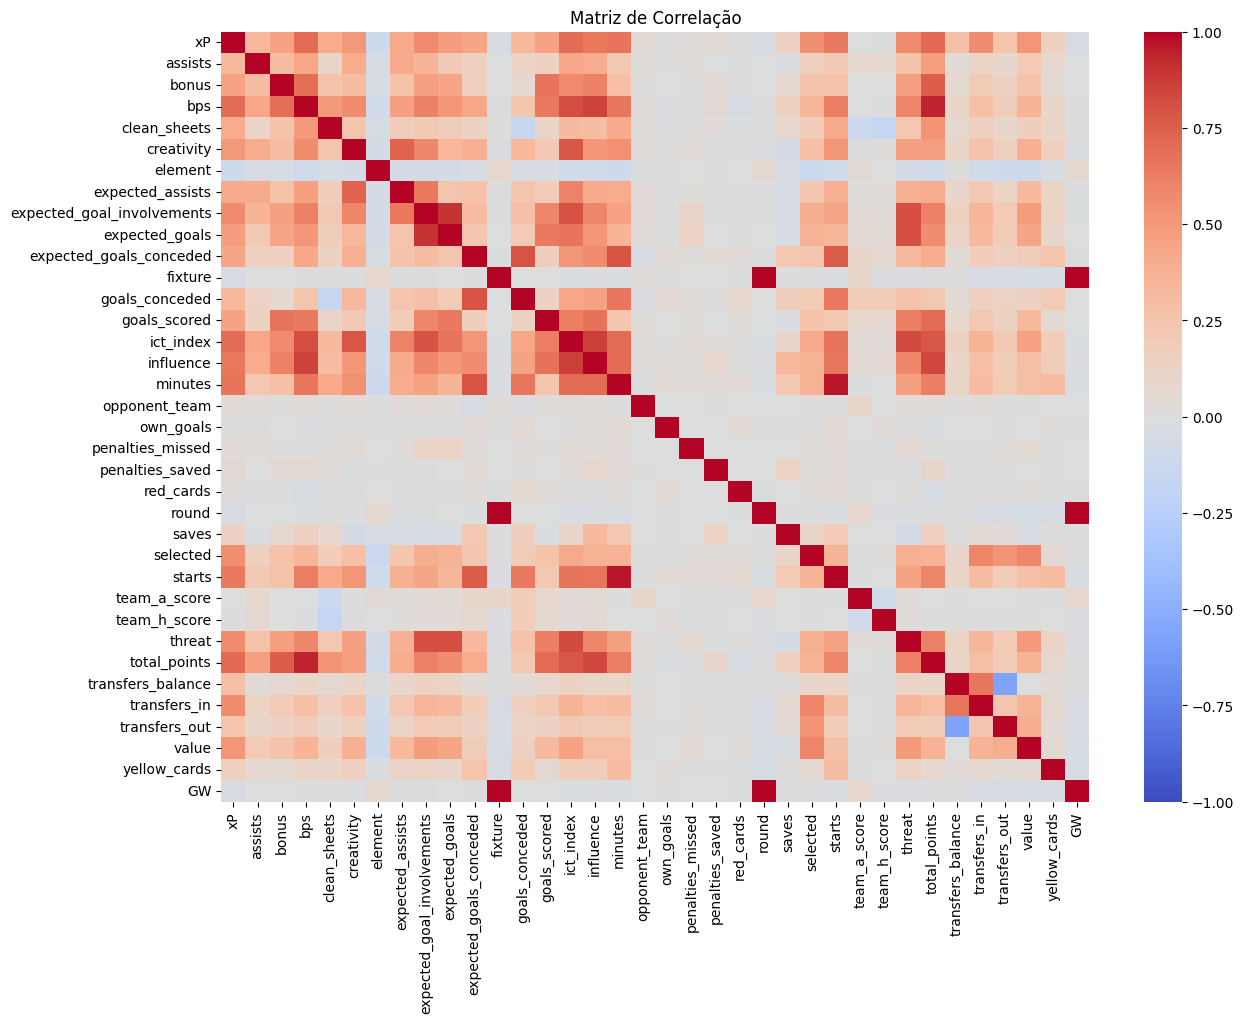

In [19]:
# compute correlation only on numeric columns to avoid string conversion errors
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

---

## 8. Engenharia de Atributos para o Apriori

Uma vez que o algoritmo Apriori opera sobre atributos **binários/categóricos**, é necessário transformar métricas contínuas em indicadores booleanos.

Assim, criam-se atributos como:

- high_points → jogador fez 8 ou mais pontos  
- played_60_plus → jogou pelo menos 60 minutos  
- goal_scored_flag → marcou pelo menos um golo  
- assist_flag → fez assistência  
- clean_sheet_flag → manteve clean sheet  
- high_influence / high_threat / high_creativity → métricas superiores à mediana

Estas variáveis definem a base transacional necessária para extração de regras de associação.

In [20]:
df['high_points'] = df['total_points'] >= 8
df['played_60_plus'] = df['minutes'] >= 60
df['goal_scored_flag'] = df['goals_scored'] > 0
df['assist_flag'] = df['assists'] > 0
df['clean_sheet_flag'] = df['clean_sheets'] > 0
df['high_influence'] = df['influence'] > df['influence'].median()
df['high_threat'] = df['threat'] > df['threat'].median()
df['high_creativity'] = df['creativity'] > df['creativity'].median()

---

## 9. Construção do Dataset Final para Regras de Associação

Após a criação dos atributos binários, selecionam-se apenas estes indicadores para formar o dataset que será utilizado pelo algoritmo Apriori.

Cada linha representa agora uma "transação" correspondente ao desempenho de um jogador numa jornada, descrita através da presença/ausência de determinados eventos.

In [21]:
df_transactions = df[['high_points', 'played_60_plus', 'goal_scored_flag',
                      'assist_flag', 'clean_sheet_flag',
                      'high_influence', 'high_threat', 'high_creativity']]

df_transactions.head()

,high_points,played_60_plus,goal_scored_flag,assist_flag,clean_sheet_flag,high_influence,high_threat,high_creativity
0,False,True,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,True,False,False,False,True,True,True


---

## 10. Conclusões da EDA

A análise exploratória permitiu concluir que:

1. O ficheiro `merged_gw.csv` apresenta informação altamente detalhada e adequada para análise de padrões de performance no FPL.
2. A limpeza e normalização dos dados foram essenciais para garantir consistência e qualidade:
   - conversão de tipos,
   - análise rigorosa dos nulos,
   - estudo das distribuições e relações entre métricas.
3. A criação de atributos binários foi fundamental para adaptar o dataset ao algoritmo Apriori.
4. O dataset final apresenta-se limpo, legível e estruturado, permitindo avançar para a análise de regras de associação.
5. Dado o tipo de atributos criados, será possível extrair regras como:
   - Jogadores que marcam golos tendem também a obter bónus ou alta influência.
   - Jogadores que jogam mais de 60 minutos têm maior probabilidade de atingir limiares de ameaça (threat).
   - Jogadores com boa performance ofensiva frequentemente exibem também elevada criatividade.

Com este trabalho, encontra-se concluída a EDA e inicia-se a fase de mineração de padrões.